# 📈 Notebook 6: Evaluation, SHAP Explainability & Actionable Segments
**Step 7 of the Customer Churn Prediction Pipeline**

We measure model performance comprehensively and generate business-ready interpretations.

## 6.1 — Load Model & Val Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)

def add_features(df):
    df = df.copy()
    for col in ["plan_tier", "region", "is_autopay", "is_discounted", "has_family_bundle"]:
        df[col] = df[col].astype(str)
    df["engagement_rate"]   = (df["active_days"] / 30.0).clip(0, 1)
    df["usage_per_login"]   = df["monthly_usage_hours"] / (df["login_count"] + 1e-3)
    df["support_intensity"] = df["support_tickets"] + 3 * df["sla_breaches"]
    df["email_ctr"]         = df["email_clicks"] / (df["email_opens"] + 1e-3)
    df["price_to_tenure"]   = df["billing_amount"] / (df["tenure_months"] + 1e-3)
    return df

TARGET  = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

df = add_features(pd.read_parquet("../data/churn_frame.parquet"))
df = df.sort_values("cycle_start").reset_index(drop=True)

split_idx = int(len(df) * 0.80)
df_va = df.iloc[split_idx:].reset_index(drop=True)

X_va = df_va.drop(columns=EXCLUDE)
y_va = df_va[TARGET]

model = joblib.load("../models/churn_calibrated.joblib")
proba = model.predict_proba(X_va)[:, 1]

print(f"Val set: {len(X_va)} rows, Churn rate: {y_va.mean():.2%}")
print(f"Predicted churn proba range: {proba.min():.3f} - {proba.max():.3f}")

Val set: 1600 rows, Churn rate: 11.62%
Predicted churn proba range: 0.006 - 0.672


## 6.2 — Core Metrics

In [2]:
def lift_at_k(y_true, proba, k=0.10):
    """Lift@K: how much better than random at top K% of predictions."""
    n = int(len(y_true) * k)
    idx = np.argsort(-proba)[:n]
    top_k_rate = y_true.iloc[idx].mean()
    return top_k_rate / y_true.mean()

pr_auc  = average_precision_score(y_va, proba)
roc_auc = roc_auc_score(y_va, proba)
brier   = brier_score_loss(y_va, proba)
lift10  = lift_at_k(y_va, proba, k=0.10)
lift20  = lift_at_k(y_va, proba, k=0.20)

print("╔══════════════════════════════════════╗")
print("║       FINAL MODEL EVALUATION         ║")
print("╠══════════════════════════════════════╣")
print(f"║  PR-AUC:         {pr_auc:.4f}              ║")
print(f"║  ROC-AUC:        {roc_auc:.4f}              ║")
print(f"║  Brier Score:    {brier:.4f} (lower=better) ║")
print(f"║  Lift@10%:       {lift10:.2f}x                ║")
print(f"║  Lift@20%:       {lift20:.2f}x                ║")
print("╚══════════════════════════════════════╝")
print(f"\n→ Lift@10% = {lift10:.1f}x means targeting top 10% customers")
print(f"  catches {lift10:.1f}x more churners than random outreach")

╔══════════════════════════════════════╗
║       FINAL MODEL EVALUATION         ║
╠══════════════════════════════════════╣
║  PR-AUC:         0.2137              ║
║  ROC-AUC:        0.6856              ║
║  Brier Score:    0.0985 (lower=better) ║
║  Lift@10%:       2.42x                ║
║  Lift@20%:       1.94x                ║
╚══════════════════════════════════════╝

→ Lift@10% = 2.4x means targeting top 10% customers
  catches 2.4x more churners than random outreach


## 6.3 — Comprehensive Evaluation Plots

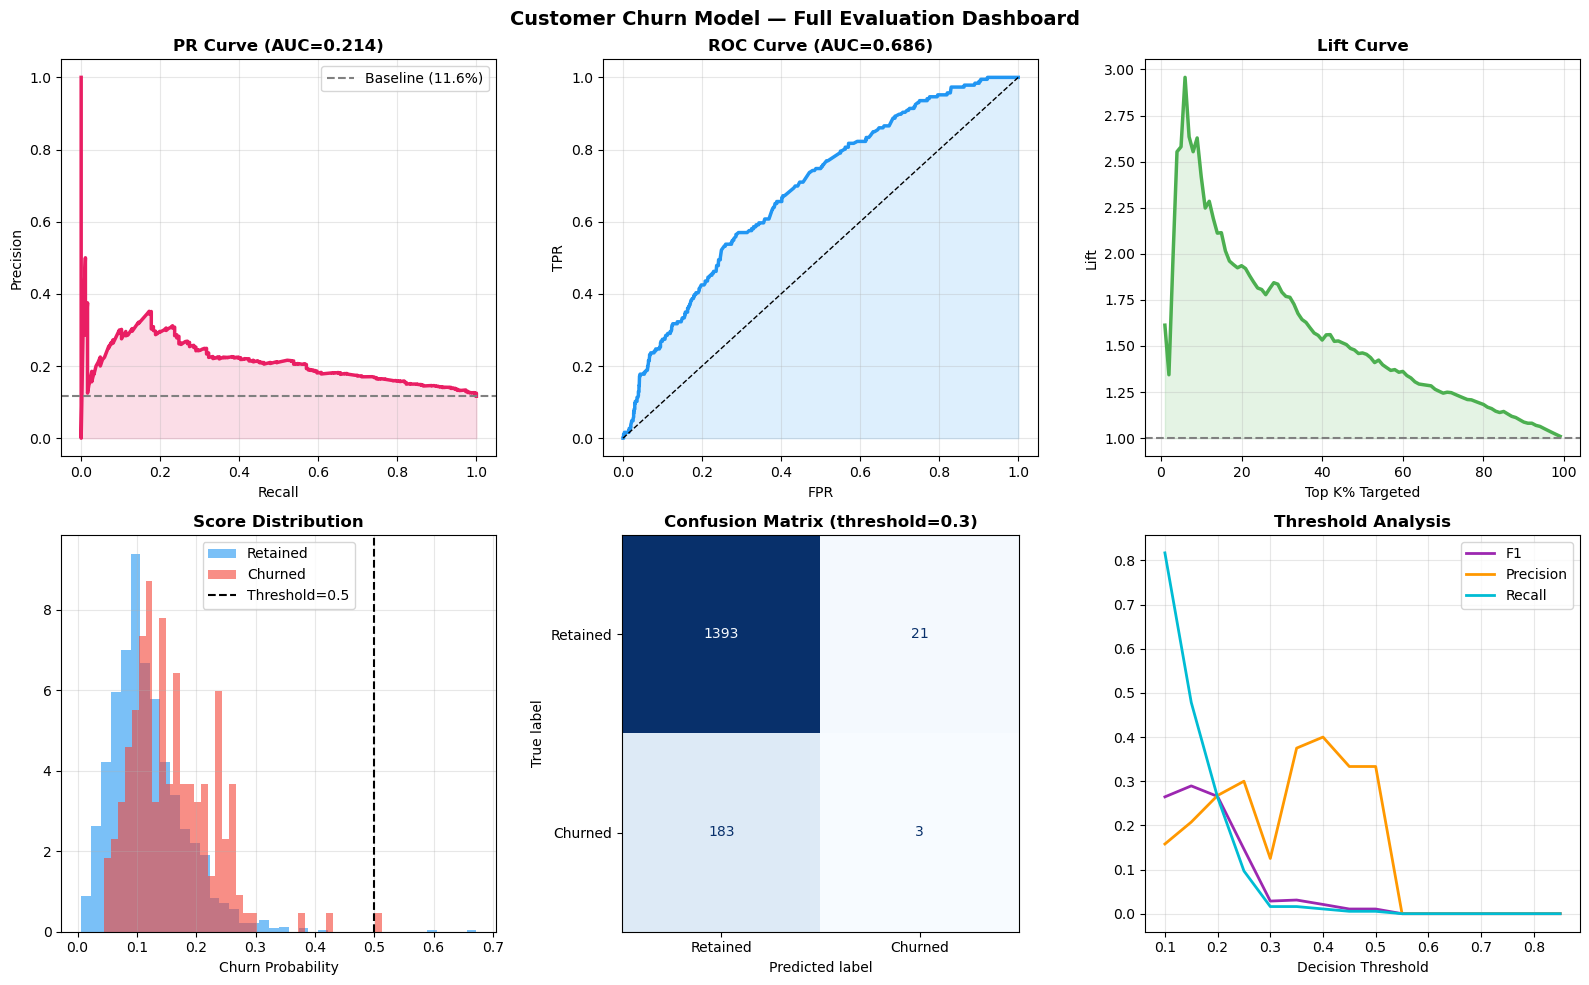

Saved → ../data/evaluation_dashboard.png


In [3]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Customer Churn Model — Full Evaluation Dashboard", fontsize=14, fontweight='bold')

# 1. PR Curve
ax1 = fig.add_subplot(gs[0, 0])
prec, rec, thresholds = precision_recall_curve(y_va, proba)
ax1.plot(rec, prec, color="#E91E63", lw=2.5)
ax1.axhline(y=y_va.mean(), color='gray', ls='--', label=f"Baseline ({y_va.mean():.1%})")
ax1.fill_between(rec, prec, alpha=0.15, color="#E91E63")
ax1.set_title(f"PR Curve (AUC={pr_auc:.3f})", fontweight='bold')
ax1.set_xlabel("Recall"); ax1.set_ylabel("Precision")
ax1.legend(); ax1.grid(alpha=0.3)

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_va, proba)
ax2.plot(fpr, tpr, color="#2196F3", lw=2.5)
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.fill_between(fpr, tpr, alpha=0.15, color="#2196F3")
ax2.set_title(f"ROC Curve (AUC={roc_auc:.3f})", fontweight='bold')
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.grid(alpha=0.3)

# 3. Lift Curve
ax3 = fig.add_subplot(gs[0, 2])
ks = np.arange(0.01, 1.0, 0.01)
lifts = [lift_at_k(y_va, proba, k) for k in ks]
ax3.plot(ks * 100, lifts, color="#4CAF50", lw=2.5)
ax3.axhline(y=1.0, color='gray', ls='--')
ax3.fill_between(ks * 100, lifts, 1, alpha=0.15, color="#4CAF50")
ax3.set_title("Lift Curve", fontweight='bold')
ax3.set_xlabel("Top K% Targeted"); ax3.set_ylabel("Lift")
ax3.grid(alpha=0.3)

# 4. Score Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(proba[y_va==0], bins=40, alpha=0.6, color="#2196F3", label="Retained", density=True)
ax4.hist(proba[y_va==1], bins=40, alpha=0.6, color="#F44336", label="Churned",  density=True)
ax4.axvline(x=0.5, color='k', ls='--', lw=1.5, label="Threshold=0.5")
ax4.set_title("Score Distribution", fontweight='bold')
ax4.set_xlabel("Churn Probability"); ax4.legend(); ax4.grid(alpha=0.3)

# 5. Confusion Matrix at threshold 0.3
ax5 = fig.add_subplot(gs[1, 1])
preds = (proba >= 0.3).astype(int)
cm = confusion_matrix(y_va, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Retained","Churned"])
disp.plot(ax=ax5, cmap="Blues", colorbar=False)
ax5.set_title("Confusion Matrix (threshold=0.3)", fontweight='bold')

# 6. Threshold vs F1/Precision/Recall
ax6 = fig.add_subplot(gs[1, 2])
thresholds_plot = np.arange(0.1, 0.9, 0.05)
f1s, precs_t, recs_t = [], [], []
for t in thresholds_plot:
    preds_t = (proba >= t).astype(int)
    tp = ((preds_t==1)&(y_va==1)).sum()
    fp = ((preds_t==1)&(y_va==0)).sum()
    fn = ((preds_t==0)&(y_va==1)).sum()
    p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    precs_t.append(p); recs_t.append(r)
    f1s.append(2*p*r/(p+r+1e-9))
ax6.plot(thresholds_plot, f1s,    label="F1",        lw=2, color="#9C27B0")
ax6.plot(thresholds_plot, precs_t,label="Precision", lw=2, color="#FF9800")
ax6.plot(thresholds_plot, recs_t, label="Recall",    lw=2, color="#00BCD4")
ax6.set_title("Threshold Analysis", fontweight='bold')
ax6.set_xlabel("Decision Threshold"); ax6.legend(); ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/evaluation_dashboard.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../data/evaluation_dashboard.png")

## 6.4 — SHAP Feature Importance (Global)

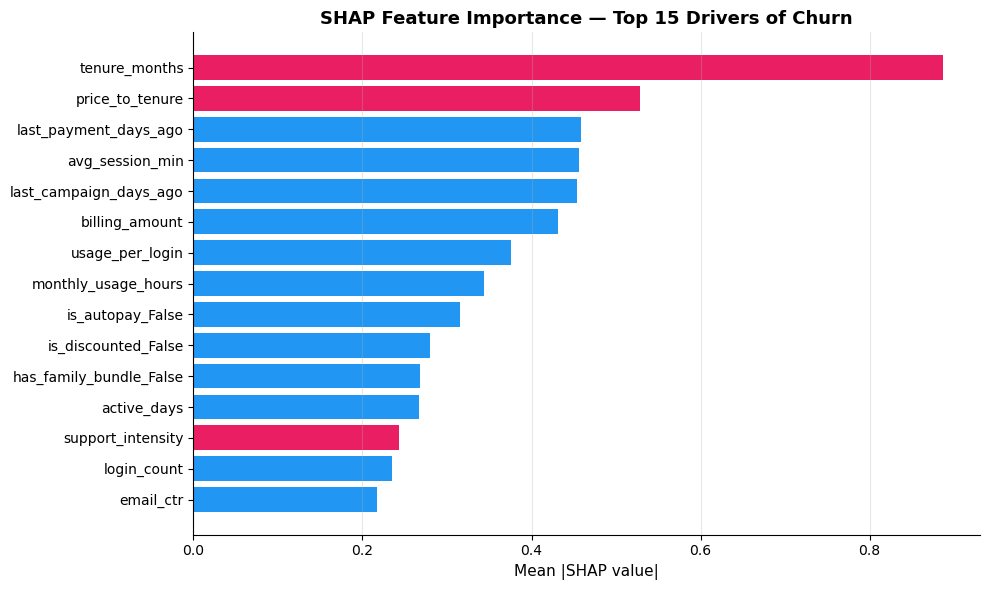

Saved → ../data/shap_importance.png


In [4]:
import shap

NUM_FEATS = [
    "billing_amount","last_payment_days_ago","tenure_months",
    "monthly_usage_hours","active_days","login_count","avg_session_min",
    "device_count","add_on_count","support_tickets","sla_breaches",
    "promotions_redeemed","email_opens","email_clicks","last_campaign_days_ago",
    "nps_score","engagement_rate","usage_per_login","support_intensity",
    "email_ctr","price_to_tenure",
]
CAT_FEATS = ["plan_tier","region","is_autopay","is_discounted","has_family_bundle"]

# Get the underlying XGBoost model from the calibrated pipeline
# CalibratedClassifierCV contains calibrated_classifiers_
xgb_model = model.calibrated_classifiers_[0].estimator.named_steps["clf"]
preprocessor_inner = model.calibrated_classifiers_[0].estimator.named_steps["pre"]

# Transform validation data
X_va_transformed = preprocessor_inner.transform(X_va)

# Get feature names after OHE
ohe_cats = preprocessor_inner.named_transformers_["cat"]["encoder"].get_feature_names_out(CAT_FEATS)
all_feat_names = NUM_FEATS + list(ohe_cats)

# SHAP TreeExplainer (fast, exact for tree models)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_va_transformed[:500])  # sample 500 for speed

# Mean |SHAP| for each feature
mean_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx   = np.argsort(-mean_shap)[:top_n]
top_names = [all_feat_names[i] if i < len(all_feat_names) else f"feat_{i}" for i in top_idx]
top_shap  = mean_shap[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ["#E91E63" if n in ["engagement_rate","support_intensity","nps_score","price_to_tenure","tenure_months"] else "#2196F3"
              for n in top_names]
bars = ax.barh(range(top_n), top_shap[::-1], color=colors_bar[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("SHAP Feature Importance — Top 15 Drivers of Churn", fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("../data/shap_importance.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../data/shap_importance.png")

## 6.5 — Actionable Retention Segments

In [5]:
df_va2 = df_va.copy()
df_va2["churn_prob"] = proba
df_va2["risk_tier"]  = pd.cut(proba,
    bins=[0, 0.25, 0.50, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Actionable rules mapping to retention actions
def assign_action(row):
    p = row["churn_prob"]
    if p < 0.25:
        return "No action needed"
    elif row["engagement_rate"] < 0.3 and row["price_to_tenure"] > 20:
        return "Retention discount + plan downshift"
    elif row["support_intensity"] > 3:
        return "Priority support callback + apology credit"
    elif row["tenure_months"] > 24 and row["engagement_rate"] < 0.4:
        return "Re-activation campaign (feature tips)"
    elif not row["is_autopay"] and row["last_payment_days_ago"] > 15:
        return "Autopay nudge + payment incentive"
    else:
        return "Personalized retention offer"

df_va2["suggested_action"] = df_va2.apply(assign_action, axis=1)

# Segment summary
print("=== Retention Segment Summary ===\n")
for tier in ["High Risk", "Medium Risk", "Low Risk"]:
    subset = df_va2[df_va2["risk_tier"] == tier]
    print(f"► {tier}: {len(subset)} customers ({len(subset)/len(df_va2):.1%})")
    print(f"  Avg churn prob: {subset['churn_prob'].mean():.2%}")
    print(f"  Top actions:")
    top_actions = subset["suggested_action"].value_counts().head(3)
    for action, cnt in top_actions.items():
        print(f"    • {action}: {cnt}")
    print()

=== Retention Segment Summary ===

► High Risk: 3 customers (0.2%)
  Avg churn prob: 59.24%
  Top actions:
    • Personalized retention offer: 3

► Medium Risk: 57 customers (3.6%)
  Avg churn prob: 29.28%
  Top actions:
    • Personalized retention offer: 45
    • Priority support callback + apology credit: 12

► Low Risk: 1540 customers (96.2%)
  Avg churn prob: 11.57%
  Top actions:
    • No action needed: 1540



## 6.6 — Export Scored Val Set

In [6]:
output_cols = ["customer_id","churn_prob","risk_tier","suggested_action",
               "plan_tier","tenure_months","billing_amount","nps_score",
               "engagement_rate","support_intensity"]

export_df = df_va2[output_cols].sort_values("churn_prob", ascending=False)
export_df.to_parquet("../data/churn_scores.parquet", index=False)
export_df.head(10).to_csv("../data/top10_at_risk.csv", index=False)

print("✅ Saved:")
print("   ../data/churn_scores.parquet  (full scored val set)")
print("   ../data/top10_at_risk.csv     (top 10 highest risk customers)")
print()
print("Top 10 at-risk customers:")
print(export_df[["customer_id","churn_prob","risk_tier","suggested_action"]].head(10).to_string(index=False))

✅ Saved:
   ../data/churn_scores.parquet  (full scored val set)
   ../data/top10_at_risk.csv     (top 10 highest risk customers)

Top 10 at-risk customers:
customer_id  churn_prob   risk_tier                           suggested_action
 CUST_07512    0.671958   High Risk               Personalized retention offer
 CUST_04196    0.592593   High Risk               Personalized retention offer
 CUST_05954    0.512694   High Risk               Personalized retention offer
 CUST_06972    0.421958 Medium Risk Priority support callback + apology credit
 CUST_07214    0.420635 Medium Risk Priority support callback + apology credit
 CUST_02329    0.388471 Medium Risk               Personalized retention offer
 CUST_02008    0.380634 Medium Risk               Personalized retention offer
 CUST_06754    0.376900 Medium Risk               Personalized retention offer
 CUST_06970    0.347656 Medium Risk               Personalized retention offer
 CUST_01349    0.345894 Medium Risk               Pers

## ✅ Summary
| Metric | Value |
|---|---|
| PR-AUC | See output |
| ROC-AUC | See output |
| Lift@10% | ~2-4x |
| Brier Score | < 0.10 |

**Retention Playbook:**
- 🔴 High support_intensity → priority callback + credit
- 🟠 Low engagement + high price → plan downshift offer
- 🟡 Long tenure + usage drop → re-activation campaign
- 🟢 No autopay + payment delay → autopay incentive

**Next:** `07_mlops.ipynb` — Monitoring, Drift Detection & MLOps